### post Genrator

In [15]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
load_dotenv()

True

In [18]:
#clean the and get jeson output
import re

def extract_json_from_markdown(text: str) -> str:
    match = re.search(r"```(?:json)?\s*({.*})\s*```", text, re.DOTALL)
    if match:
        return match.group(1)
    return text  # fallback if not wrapped

In [11]:
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')

In [12]:
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [16]:

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [33]:
import operator
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal['approved','need_improvement']
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str],operator.add]
    feedback_history: Annotated[list[str],operator.add]

In [34]:
def genrate_tweet(state: TweetState):

    #prompt
    messages = [
    SystemMessage(content="You are a funny and clever Twitter/X influencer."),
    HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
            ]
    
    # send genrator_llm
    response = llm.invoke(messages).content

    #return responce
    return {'tweet':response, 'tweet_history':[response]}

In [35]:
import json
import ast
from langchain_core.output_parsers import PydanticOutputParser
# response want in json
parser = PydanticOutputParser(pydantic_object=TweetEvaluation)
format_instructions = parser.get_format_instructions()


def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        \n Format instructions:{format_instructions}
        """)
        ] 
    
    # After llm.invoke(prompt).content
    raw_output = llm.invoke(messages).content
    json_output = extract_json_from_markdown(raw_output)
    #result = json.loads(str(json_output))
    result = ast.literal_eval(str(json_output))
    
    return {'evaluation': result['evaluation'], 'feedback': result['feedback'], 'feedback_history': [result['feedback']]}


In [21]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
            Improve the tweet based on this feedback:
            "{state['feedback']}"

            Topic: "{state['topic']}"
            Original Tweet:
            {state['tweet']}

            Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
            """)
                ]
    
    response = llm.invoke(messages).content
    iteration = state['iteration'] + 1
    
    return {'tweet':response, 'iteration': iteration}


In [23]:
def route_condition(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration']>=state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'



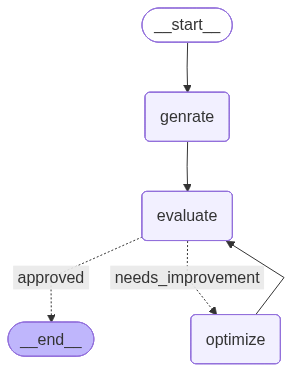

In [36]:
graph = StateGraph(TweetState)

graph.add_node('genrate', genrate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize',optimize_tweet)

graph.add_edge(START,'genrate')
graph.add_edge('genrate','evaluate')

graph.add_conditional_edges('evaluate', route_condition, {'approved': END, 'needs_improvement':'optimize'})

graph.add_edge('optimize','evaluate')

workflow = graph.compile()
workflow


In [38]:
initial_state = {
    "topic": "Statistics",
    "iteration" : 1,
    "max_iteration": 5
}

final_state = workflow.invoke(initial_state)
final_state

{'topic': 'Statistics',
 'tweet': '"Just learned 99% of stats are made up, which ironically is a statistic" #StatsLife',
 'evaluation': 'approved',
 'feedback': "This tweet is a great example of a well-crafted joke, with a clever play on the idea that '99% of stats are made up.' The humor is dry and ironic, and the punchline is quick and scroll-stopping. The tweet is also short and concise, making it easy to read and understand. The use of the hashtag #StatsLife adds a touch of relevance and context to the joke. Overall, this tweet has strong originality, humor, and virality potential, making it a great candidate for approval.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"Just learned 99% of stats are made up, which ironically is a statistic" #StatsLife'],
 'feedback_history': ["This tweet is a great example of a well-crafted joke, with a clever play on the idea that '99% of stats are made up.' The humor is dry and ironic, and the punchline is quick and scroll-stopping. 